In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

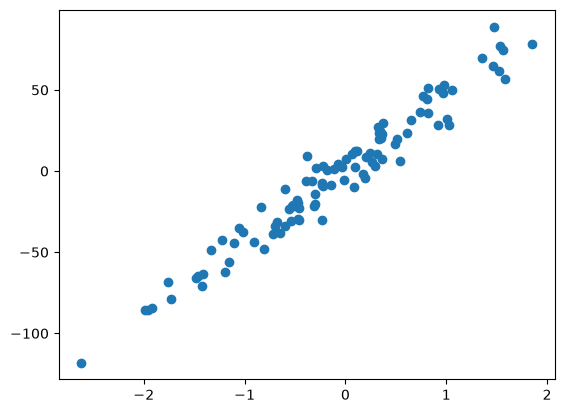

In [2]:
x, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
plt.scatter(x, y)

In [3]:
print(x.shape, y.shape)

(100, 1) (100,)


In [4]:
y = y.reshape(y.shape[0], 1)  # Reshape y to be a column vector

In [5]:
# matrice X
X = np.hstack((x, np.ones(x.shape)))
print(x.shape, y.shape, X.shape)

(100, 1) (100, 1) (100, 2)


In [6]:
theta = np.random.randn(2, 1)  # Random initialization of theta
theta.shape

(2, 1)

In [7]:
def model(X, theta):
    return X.dot(theta)

model(X, theta)

array([[-0.85767485],
       [-0.71638034],
       [-0.52478867],
       [-0.75440556],
       [-0.62161508],
       [-0.81021173],
       [-0.62425217],
       [-0.79261697],
       [-0.80418456],
       [-0.86976738],
       [-0.83936893],
       [-0.95922424],
       [-0.82540473],
       [-0.66504652],
       [-0.56649876],
       [-0.71716924],
       [-0.37383286],
       [-0.78771443],
       [-0.87436432],
       [-0.26335985],
       [-0.784944  ],
       [-0.71805908],
       [-0.62386521],
       [-0.85501743],
       [-0.96367732],
       [-0.9471091 ],
       [-0.60128626],
       [-0.69581576],
       [-0.60110753],
       [-0.50160943],
       [-0.76157967],
       [-0.76469021],
       [-0.74550311],
       [-0.61314879],
       [-0.54984091],
       [-0.73475931],
       [-0.65176859],
       [-0.76233674],
       [-0.83947645],
       [-0.65299263],
       [-0.7622965 ],
       [-0.58851916],
       [-0.95671265],
       [-0.61507181],
       [-0.66262284],
       [-0

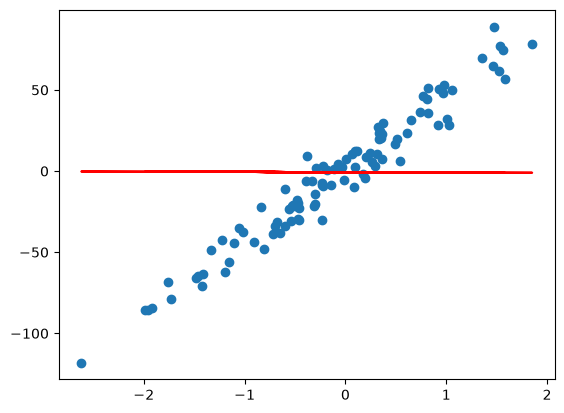

In [8]:
plt.scatter(x, y)
plt.plot(x, model(X, theta), color='red')

In [9]:
def cost_function(X, y, theta):
    m = len(y)
    predictions = model(X, theta)
    cost = (1/(2*m)) * np.sum(np.square(predictions - y))
    return cost

In [10]:
cost_function(X, y, theta)

np.float64(855.1117890875647)

In [11]:
def grad(X, y, theta):
    m = len(y)
    return (1/m) * X.T.dot(model(X, theta) - y)

In [12]:
def gradient_descent(X, y, theta, learning_rate=0.01, iterations=1000):
    cost_history = np.zeros(iterations)
    for i in range(iterations):
        theta -= learning_rate * grad(X, y, theta)
        cost_history[i] = cost_function(X, y, theta)

    return theta, cost_history

In [13]:
theta_final, cost_history = gradient_descent(X, y, theta, learning_rate=0.05, iterations=100)

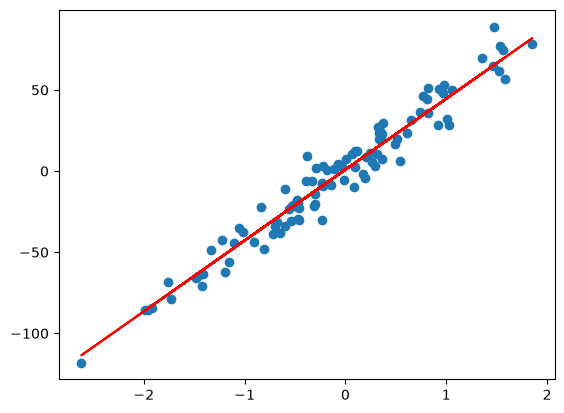

In [14]:
plt.scatter(x, y)
plt.plot(x, model(X, theta_final), color='red')

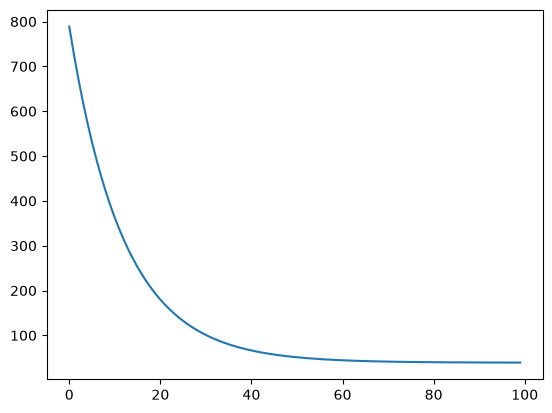

In [15]:
plt.plot(cost_history)

In [16]:
def coef_deter(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)

predictions = model(X, theta_final)
r_squared = coef_deter(y, predictions)
r_squared


np.float64(0.9535436449685791)

In [17]:
cost = cost_function(X, y, theta)
cost

np.float64(39.26513573217712)